# 🚨 Sovereign-Dispatch — Training Model Klasifikasi Triase
**Model:** Text Classification (KRITIS / WASPADA / INFO)

**Base Model:** `indobenchmark/indobert-base-p1`

**Dataset:** `data_latih.csv` — 1.198 pesan Bahasa Aceh / Dialek Lokal

---
### Struktur Notebook
1. Install & Import
2. Load & Periksa Dataset
3. Preprocessing
4. Tokenisasi & Dataset Split
5. Training dengan Focal Loss
6. Evaluasi Metrik
7. Simpan Model

## 1. Install & Import Library

In [7]:
# ⚡ Jalankan sekali di awal (Colab / environment baru)
!pip install transformers datasets scikit-learn seaborn matplotlib torch -q


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, recall_score, precision_score
)
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer
)
from datasets import Dataset
import warnings
warnings.filterwarnings('ignore')

# Cek GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'✅ Device: {device}')
if device == 'cuda':
    print(f'   GPU: {torch.cuda.get_device_name(0)}')

✅ Device: cpu


## 2. Load & Periksa Dataset

In [9]:
# ── Load CSV ──────────────────────────────────────────────────────────────
# Ganti path jika diperlukan
DATA_PATH = 'data_latih.csv'

df = pd.read_csv(DATA_PATH, sep=';', skiprows=1)
df.columns = ['No', 'pesan', 'label']
df = df[['pesan', 'label']].dropna().reset_index(drop=True)

print(f'Total data : {len(df)} baris')
print(f'Distribusi label:')
print(df['label'].value_counts())
print()
print('Contoh 5 baris pertama:')
df.head()

Total data : 1198 baris
Distribusi label:
label
KRITIS     400
INFO       400
WASPADA    398
Name: count, dtype: int64

Contoh 5 baris pertama:


,pesan,label
0,"Tulong! Aneuk loen karam di krueng, hana deuh le!",KRITIS
1,"Rumah kamo ka keunong apui, tulong bantu sigra!",KRITIS
2,"Na ureung meukeureuphap lam mobel, darurat di ...",KRITIS
3,"Ie ka jitamong lam rumoh deungon rayeuk that, ...",KRITIS
4,"Tulong! Ayah loen hana sanggob meunapas le, ji...",KRITIS


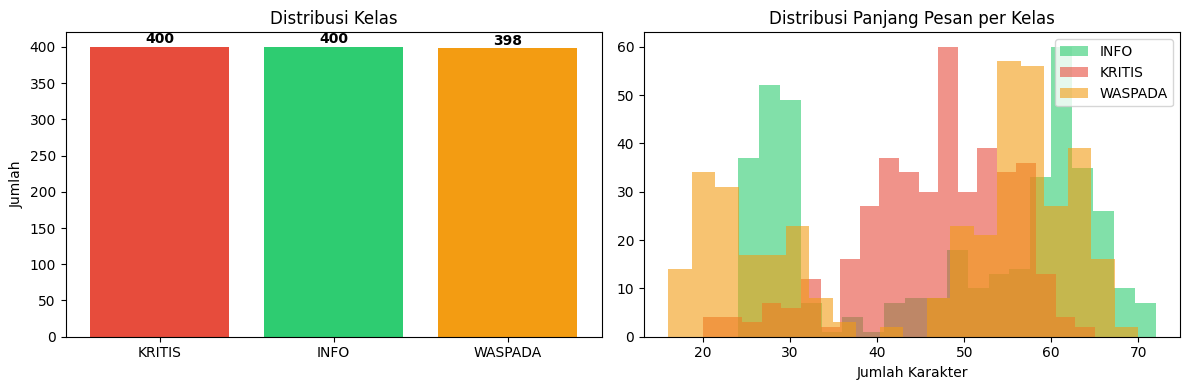

✅ Plot disimpan: distribusi_dataset.png


In [10]:
# Visualisasi distribusi kelas
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = {'KRITIS': '#e74c3c', 'WASPADA': '#f39c12', 'INFO': '#2ecc71'}
counts = df['label'].value_counts()

axes[0].bar(counts.index, counts.values,
            color=[colors.get(l, 'gray') for l in counts.index])
axes[0].set_title('Distribusi Kelas')
axes[0].set_ylabel('Jumlah')
for i, (k, v) in enumerate(counts.items()):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Distribusi panjang pesan
df['panjang'] = df['pesan'].str.len()
for label, grp in df.groupby('label'):
    axes[1].hist(grp['panjang'], bins=20, alpha=0.6,
                 label=label, color=colors.get(label, 'gray'))
axes[1].set_title('Distribusi Panjang Pesan per Kelas')
axes[1].set_xlabel('Jumlah Karakter')
axes[1].legend()

plt.tight_layout()
plt.savefig('distribusi_dataset.png', dpi=150)
plt.show()
print('✅ Plot disimpan: distribusi_dataset.png')

## 3. Preprocessing

In [11]:
import re

# ── Kamus normalisasi singkatan panik ──────────────────────────────────────
KAMUS_SINGKATAN = {
    r'\btlg\b': 'tolong',
    r'\bbantu\b': 'bantu',
    r'\blsg\b': 'langsung',
    r'\bsgr\b': 'segera',
    r'\bdrrt\b': 'darurat',
    r'\bdrt\b': 'darurat',
    r'\bpls\b': 'tolong',
    r'\bkrg\b': 'kurang',
    r'\bskt\b': 'sakit',
    r'\bukrg\b': 'aneuk',       # Aceh: anak
    r'\blkgn\b': 'lingkungan',
}

def preprocess(text: str) -> str:
    """
    Preprocessing context-aware:
    - PERTAHANKAN tanda seru dan huruf kapital (sinyal panik)
    - Normalisasi singkatan
    - Hapus karakter tidak relevan (bukan huruf/angka/tanda darurat)
    """
    text = str(text)
    # Normalisasi singkatan
    for pola, ganti in KAMUS_SINGKATAN.items():
        text = re.sub(pola, ganti, text, flags=re.IGNORECASE)
    # Hapus karakter aneh tapi PERTAHANKAN ! ? huruf & angka
    text = re.sub(r'[^\w\s!?,.]', ' ', text)
    # Hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['pesan_bersih'] = df['pesan'].apply(preprocess)

print('Contoh hasil preprocessing:')
for _, row in df.sample(5, random_state=42).iterrows():
    print(f'  [{row["label"]}]')
    print(f'   Asli  : {row["pesan"]}')
    print(f'   Bersih: {row["pesan_bersih"]}')
    print()

Contoh hasil preprocessing:
  [INFO]
   Asli  : Berapa kekuatan guncangan gempa utama menurut rilis BMKG?
   Bersih: Berapa kekuatan guncangan gempa utama menurut rilis BMKG?

  [INFO]
   Asli  : Pak, apakah jalan menuju Banda Aceh sudah dibuka untuk truk logistik?
   Bersih: Pak, apakah jalan menuju Banda Aceh sudah dibuka untuk truk logistik?

  [KRITIS]
   Asli  : Tulong! Bak kayee rhot u ateuh rumoh, help!
   Bersih: Tulong! Bak kayee rhot u ateuh rumoh, help!

  [INFO]
   Asli  : Peu na rencana jipeugeuet jambatan darurat jinoe?
   Bersih: Peu na rencana jipeugeuet jambatan darurat jinoe?

  [KRITIS]
   Asli  : Na ledakan tabung gas, ureung lam dapu keunong apui!
   Bersih: Na ledakan tabung gas, ureung lam dapu keunong apui!



## 4. Tokenisasi & Dataset Split (Stratified 70/15/15)

In [12]:
# ── Label encoding ─────────────────────────────────────────────────────────
LABEL2ID = {'KRITIS': 0, 'WASPADA': 1, 'INFO': 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}

df['label_id'] = df['label'].map(LABEL2ID)

# ── Stratified Split 70 / 15 / 15 ─────────────────────────────────────────
X = df['pesan_bersih'].values
y = df['label_id'].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

print(f'Train : {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)')
print(f'Val   : {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)')
print(f'Test  : {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)')

TypeError: only integer scalar arrays can be converted to a scalar index

In [ ]:
# ── Load Tokenizer ─────────────────────────────────────────────────────────
# IndoBERT: model BERT yang sudah pre-trained di bahasa Indonesia
# Pilihan alternatif jika mau lebih kecil: 'cahya/bert-base-indonesian-522M'
MODEL_NAME = 'indobenchmark/indobert-base-p1'
MAX_LEN = 128

print(f'⏳ Memuat tokenizer: {MODEL_NAME}')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print('✅ Tokenizer siap')

def tokenize(batch):
    return tokenizer(
        batch['text'],
        padding='max_length',
        truncation=True,
        max_length=MAX_LEN
    )

def make_dataset(texts, labels):
    ds = Dataset.from_dict({'text': list(texts), 'labels': list(labels)})
    return ds.map(tokenize, batched=True)

print('⏳ Tokenisasi dataset...')
train_ds = make_dataset(X_train, y_train)
val_ds   = make_dataset(X_val,   y_val)
test_ds  = make_dataset(X_test,  y_test)
print('✅ Tokenisasi selesai')

## 5. Training dengan Focal Loss

In [ ]:
# ── Focal Loss ─────────────────────────────────────────────────────────────
# Memberi penalti besar jika AI melewatkan kelas KRITIS
class FocalLoss(nn.Module):
    def __init__(self, gamma: float = 2.0,
                 alpha: list = None, num_classes: int = 3):
        super().__init__()
        self.gamma = gamma
        # alpha per kelas: bobot KRITIS lebih tinggi
        if alpha is None:
            alpha = [2.0, 1.5, 1.0]   # KRITIS, WASPADA, INFO
        self.alpha = torch.tensor(alpha, dtype=torch.float)

    def forward(self, inputs, targets):
        self.alpha = self.alpha.to(inputs.device)
        CE = nn.functional.cross_entropy(
            inputs, targets, reduction='none')
        pt = torch.exp(-CE)
        alpha_t = self.alpha[targets]
        focal = alpha_t * (1 - pt) ** self.gamma * CE
        return focal.mean()

focal_loss_fn = FocalLoss(gamma=2.0)
print('✅ Focal Loss siap (gamma=2.0, alpha=[2.0, 1.5, 1.0])')

In [ ]:
# ── Custom Trainer dengan Focal Loss ──────────────────────────────────────
class FocalTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        logits = outputs.logits
        loss = focal_loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

# ── Load Base Model ────────────────────────────────────────────────────────
print(f'⏳ Memuat model: {MODEL_NAME}')
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=ID2LABEL,
    label2id=LABEL2ID
)
print('✅ Model siap')

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy' : accuracy_score(labels, preds),
        'f1_macro' : f1_score(labels, preds, average='macro'),
        # ⚠️ Recall kelas KRITIS (index 0) — target ≥ 95%
        'recall_KRITIS'   : recall_score(labels, preds, average=None)[0],
        'precision_KRITIS': precision_score(labels, preds, average=None)[0],
    }

# ── Training Arguments ────────────────────────────────────────────────────
training_args = TrainingArguments(
    output_dir            = './hasil_training',
    num_train_epochs      = 10,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 32,
    warmup_steps          = 100,
    weight_decay          = 0.01,
    learning_rate         = 2e-5,
    eval_strategy = 'epoch',
    save_strategy = 'epoch',
    load_best_model_at_end= True,
    metric_for_best_model = 'recall_KRITIS',   # prioritaskan recall KRITIS
    greater_is_better     = True,
    logging_dir           = './logs',
    logging_steps         = 50,
    fp16                  = (device == 'cuda'),
    report_to             = 'none',
)

trainer = FocalTrainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_ds,
    eval_dataset    = val_ds,
    compute_metrics = compute_metrics,
)

print('🚀 Mulai training...')
trainer.train()
print('✅ Training selesai!')

## 6. Evaluasi Metrik

In [ ]:
# ── Evaluasi di Test Set ───────────────────────────────────────────────────
preds_output = trainer.predict(test_ds)
y_pred = np.argmax(preds_output.predictions, axis=-1)
y_true = preds_output.label_ids

print('=' * 60)
print('📊 HASIL EVALUASI MODEL — TEST SET')
print('=' * 60)
print(classification_report(
    y_true, y_pred,
    target_names=['KRITIS', 'WASPADA', 'INFO']
))

# Cek apakah lolos kriteria kelulusan proposal
acc      = accuracy_score(y_true, y_pred)
f1       = f1_score(y_true, y_pred, average='macro')
rec_kritis = recall_score(y_true, y_pred, average=None)[0]
prec     = precision_score(y_true, y_pred, average='macro')

print('\n📋 CEK KRITERIA KELULUSAN MODEL:')
kriteria = [
    ('Recall  KRITIS', rec_kritis,  0.95, '≥ 95%'),
    ('Accuracy',       acc,         0.90, '≥ 90%'),
    ('F1-Score',       f1,          0.88, '≥ 88%'),
    ('Precision',      prec,        0.85, '≥ 85%'),
]
all_pass = True
for nama, nilai, target, label in kriteria:
    status = '✅ LULUS' if nilai >= target else '❌ BELUM'
    if nilai < target:
        all_pass = False
    print(f'  {status}  {nama:20s}: {nilai:.4f} (target {label})')

print()
if all_pass:
    print('🎉 SELAMAT! Model lolos semua kriteria kelulusan.')
else:
    print('⚠️  Beberapa metrik belum memenuhi target. Coba tambah epoch atau data.')

In [ ]:
# ── Confusion Matrix ───────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
labels_nama = ['KRITIS', 'WASPADA', 'INFO']

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=labels_nama, yticklabels=labels_nama)
plt.title('Confusion Matrix — Test Set', fontsize=13)
plt.ylabel('Label Sebenarnya')
plt.xlabel('Prediksi Model')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print('✅ Plot disimpan: confusion_matrix.png')

## 7. Simpan Model

In [ ]:
import os, json

SAVE_DIR = './model_klasifikasi1'
os.makedirs(SAVE_DIR, exist_ok=True)

# Simpan model & tokenizer
trainer.save_model(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

# Simpan label mapping
with open(f'{SAVE_DIR}/label_map.json', 'w') as f:
    json.dump({'label2id': LABEL2ID, 'id2label': ID2LABEL}, f, indent=2)

# Simpan ringkasan metrik
metrik_dict = {
    'accuracy': float(acc),
    'f1_macro': float(f1),
    'recall_KRITIS': float(rec_kritis),
    'precision_macro': float(prec),
    'base_model': MODEL_NAME,
    'dataset_size': len(df),
    'all_criteria_passed': all_pass
}
with open(f'{SAVE_DIR}/metrics.json', 'w') as f:
    json.dump(metrik_dict, f, indent=2)

print(f'✅ Model disimpan di: {SAVE_DIR}/')
print(f'   Isi folder: {os.listdir(SAVE_DIR)}')

In [ ]:
# ── Uji Coba Inferensi Manual ──────────────────────────────────────────────
from transformers import pipeline

classifier = pipeline(
    'text-classification',
    model=SAVE_DIR,
    tokenizer=SAVE_DIR,
    device=0 if device == 'cuda' else -1
)

pesan_uji = [
    "Tulong! Aneuk loen karam di krueng, hana deuh le!",
    "Ie ka naek sampai lutut di gampong kami, but perlu bantuan",
    "Posko makan di mana ya pak?",
    "Tlg! klrga sy 5 org kejebak ie lueng di Gampong Lambhuk!",
]

print('🧪 UJI COBA INFERENSI:')
print('-' * 70)
for pesan in pesan_uji:
    hasil = classifier(preprocess(pesan))[0]
    label = hasil['label']
    skor  = hasil['score']
    emoji = {'KRITIS': '🔴', 'WASPADA': '🟡', 'INFO': '🟢'}.get(label, '⚪')
    print(f'{emoji} [{label}] ({skor:.2%})')
    print(f'   {pesan}')
    print()